# 3. Detection and robustness

Three questions about the trends of notebook 2:

1. How large a decline can this method find at a site, in a soum or across a zone?
2. Is the national decline more than an unlucky order of good and bad years?
3. Do the results depend on the choices made about the data and the model?

- **Reads** `remainders.csv`, `site_year.csv` and `flags.csv` from `data/processed/`, and summer temperature from the release.
- **Writes** `detection_test.csv` and `robustness.csv` to `data/processed/`.

The tests follow Wessels et al. (2012), section 2.5. Every random step uses a fixed seed, so a rerun gives the same numbers.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from mn_desertification import data, detection, paths, trends
from mn_desertification.rules import MAIN_YEARS

remainders = pd.read_csv(paths.PROCESSED_DIR / "remainders.csv")
models = {"rain only": "remainder_rain", "rain + temperature": "remainder_rain_temp"}
grids = {name: trends.remainder_grid(remainders, column) for name, column in models.items()}

# Each site's soum and zone, in the same order as the rows of the grids
site_info = remainders.drop_duplicates("gid").set_index("gid").loc[grids["rain only"].index]
soums = site_info["asid"].to_numpy()
zones = site_info["zone"].to_numpy()
print("Sites × years:", grids["rain only"].shape)

Sites × years: (1485, 10)


## 1. The detection test

The real remainders share a downward pattern, so they cannot serve as data without a trend. Instead, the order of the years is shuffled, with one shuffle per zone shared by all its sites. Shuffling keeps the noise and destroys any trend.

Into each shuffled data set a decline of known size d is planted. It starts in year s and grows in a straight line to its full size in 2020. d is 10, 20, 30 or 40%, and s is 2012, 2014 or 2016. Every site, every soum (sites averaged) and every zone (sites averaged) is then tested, and the share flagged with p < 0.05 is recorded. This is repeated for 50 shuffles. With d = 0 the share flagged is the false alarm rate, which should be close to 5%.

By the rule in the [design](../docs/design.md), the study works at the smallest level where a 20% decline is found in at least 80% of trials.

In [2]:
main_years = np.arange(MAIN_YEARS[0], MAIN_YEARS[1] + 1)
print("A 20% decline starting in 2014, in log10 by year:", detection.planted_decline(0.2, 2014, main_years).round(3))

detection_runs = detection.detection_test(grids, soums, zones)   # 50 shuffles, seed 7
found = detection_runs.groupby(["model", "level", "size"])["share"].mean().unstack("size")
found.columns = [f"{int(size * 100)}%" for size in found.columns]
found.round(2)

A 20% decline starting in 2014, in log10 by year: [-0.    -0.    -0.    -0.    -0.016 -0.032 -0.048 -0.065 -0.081 -0.097]


0%   10%   20%   30%   40%
model              level                              
rain + temperature site   0.05  0.06  0.08  0.11  0.15
                   soum   0.05  0.07  0.09  0.14  0.20
                   zone   0.06  0.12  0.23  0.35  0.51
rain only          site   0.05  0.07  0.09  0.12  0.17
                   soum   0.06  0.08  0.11  0.16  0.22
                   zone   0.07  0.12  0.22  0.33  0.49

In [3]:
for model in grids:
    share_20 = found.loc[model, "20%"]
    good_enough = share_20[share_20 >= 0.8]
    print(f"{model}:", good_enough.index[0] if len(good_enough) else "no level finds a 20% decline 80% of the time")

real_shares = pd.DataFrame({model: detection.detection_shares(grid.to_numpy(), grid.columns.to_numpy(), soums, zones)
                            for model, grid in grids.items()}).T
print("\nShare of sites, soums and zones with a significant decline in the real data:")
real_shares.round(3)

rain only: no level finds a 20% decline 80% of the time
rain + temperature: no level finds a 20% decline 80% of the time

Share of sites, soums and zones with a significant decline in the real data:


,site,soum,zone
rain only,0.227,0.244,0.6
rain + temperature,0.205,0.204,0.6


False alarms are 5 to 7%, as they should be. But a 20% decline is found at only 8–9% of sites, 9–11% of soums and 22–23% of zones, so no level meets the rule. Even a 40% decline is found at a zone only half the time. A decline the size seen between degraded and intact land elsewhere (10 to 20%, Wessels et al. 2012) cannot be told from noise at any level with these data.

The real data look very different. 20–24% of sites and soums, and 3 of the 5 zones, decline significantly.

## 2. Is the real order of years unusual?

The years are shuffled 1,000 times, now in one order for all sites together. That keeps the country's good and bad years as they were and changes only their order. If shuffled orders often produce as many declining sites as the real order, the real decline could be luck.

rain only: 22.7% of sites declining; shuffled orders: median 4.2%, 95% below 12.6%; reaching the real share: 3 of 1000


rain + temperature: 20.5% of sites declining; shuffled orders: median 4.2%, 95% below 11.8%; reaching the real share: 0 of 1000


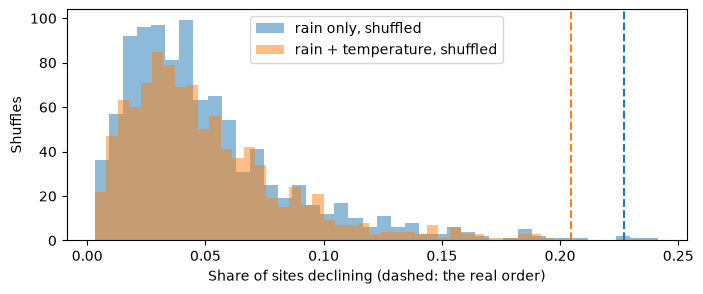

In [4]:
rng = np.random.default_rng(11)
permutations = {}
for model, grid in grids.items():
    real_share, shuffled_shares = detection.permutation_test(grid, rng)
    permutations[model] = shuffled_shares
    print(f"{model}: {real_share:.1%} of sites declining; shuffled orders: median {np.median(shuffled_shares):.1%}, "
          f"95% below {np.quantile(shuffled_shares, 0.95):.1%}; reaching the real share: "
          f"{(shuffled_shares >= real_share).sum()} of 1000")

fig, ax = plt.subplots(figsize=(8, 3))
for model, shuffled_shares in permutations.items():
    ax.hist(shuffled_shares, bins=40, alpha=0.5, label=f"{model}, shuffled")
for model, colour in zip(grids, ["tab:blue", "tab:orange"]):
    ax.axvline(real_shares.loc[model, "site"], color=colour, linestyle="--")
ax.set_xlabel("Share of sites declining (dashed: the real order)")
ax.set_ylabel("Shuffles")
ax.legend()
plt.show()

Shuffled orders reach the real share of declining sites 3 times in 1,000 with rain only and never with temperature. So the decline is not a chance ordering of ordinary good and bad years: something lowered biomass, relative to rain and temperature, across many sites between 2011 and 2020. The robustness checks below and notebook 4 narrow down what.

## 3. Robustness

Notebook 2 and the two tests above are rerun with one choice changed at a time, for both weather models:

- all years, 2007–2020, where a site needs 10 of the 14 years and declines start in 2008, 2011 or 2014;
- floors of 0.05 and 0.2 c/ha instead of 0.1;
- the three flagged values put back;
- values above 30 c/ha left out;
- **ending in 2019**, where a site needs 7 of the 9 years. This check was added after notebook 4 showed how far below the weather models 2020 fell in the dry zones.

Each check uses the same seed, so differences between checks come from the data, not from the random numbers. The first row reproduces the main analysis with its own random draws, so its counts differ slightly from those above (1 rather than 3 shuffles).

In [5]:
weather = data.read_soum_weather()
site_year = pd.read_csv(paths.PROCESSED_DIR / "site_year.csv")
site_year = site_year.merge(weather[["asid", "year", "temp_summer"]], on=["asid", "year"], how="left")
flags = pd.read_csv(paths.PROCESSED_DIR / "flags.csv")
flagged = set(zip(flags["gid"], flags["year"]))

main_starts = [2012, 2014, 2016]
checks = [
    # name, the choice changed, years a site needs, start years of the planted decline
    ("main analysis", {}, 8, main_starts),
    ("all years 2007-2020", {"first_year": 2007}, 10, [2008, 2011, 2014]),
    ("floor 0.05", {"floor": 0.05}, 8, main_starts),
    ("floor 0.2", {"floor": 0.2}, 8, main_starts),
    ("flagged values back", {"keep_flagged": True}, 8, main_starts),
    ("without values above 30", {"drop_above": 30}, 8, main_starts),
    ("end in 2019", {"last_year": 2019}, 7, main_starts),
]

rows = []
for with_temp in [False, True]:
    for name, choice, min_years, starts in checks:
        rng = np.random.default_rng(3)
        grid, check_soums, check_zones = detection.robustness_grid(site_year, flagged, with_temp=with_temp, **choice)
        result = detection.robustness_summary(grid, check_soums, check_zones, min_years, starts, rng)
        rows.append({"model": "rain + temperature" if with_temp else "rain only", "check": name, **result})

robustness = pd.DataFrame(rows)
robustness.insert(3, "% per decade", trends.percent_per_decade(robustness["national per decade"]))
robustness.round({"national per decade": 3, "% per decade": 1, "sites declining": 3,
                  "20% found: site": 2, "20% found: soum": 2, "20% found: zone": 2})

,model,check,national per decade,% per decade,sites declining,shuffles reaching it,20% found: site,20% found: soum,20% found: zone
0,rain only,main analysis,-0.283,-47.8,0.227,1,0.09,0.10,0.21
1,rain only,all years 2007-2020,0.072,18.0,0.085,141,0.09,0.11,0.19
2,rain only,floor 0.05,-0.292,-48.9,0.230,1,0.09,0.10,0.21
3,rain only,floor 0.2,-0.266,-45.9,0.225,1,0.09,0.10,0.21
4,rain only,flagged values back,-0.283,-47.9,0.228,1,0.09,0.10,0.21
5,rain only,without values above 30,-0.281,-47.7,0.228,1,0.09,0.10,0.21
6,rain only,end in 2019,-0.251,-43.9,0.170,12,0.08,0.10,0.19
7,rain + temperature,main analysis,-0.219,-39.5,0.205,0,0.09,0.11,0.25
8,rain + temperature,all years 2007-2020,0.069,17.2,0.091,117,0.09,0.11,0.25
9,rain + temperature,floor 0.05,-0.228,-40.9,0.208,0,0.09,0.11,0.25


- **The data choices do not matter.** The floor, the flagged values and values above 30 c/ha change the national trend by at most 0.017 log10 per decade and the share of declining sites by at most 0.6 points.
- **The start year does.** From 2007 the national trend turns positive, about +18% per decade, and the share of declining sites is ordinary under shuffling (117–141 of 1,000). The decline belongs to the 2011–2020 window. It reflects high values in 2011–2014, after the 2009–2010 dzud, relative to later years.
- **So does the end year, once temperature is in the model.** Without 2020 the national trend more than halves, to −0.093 log10 per decade, and 35 of 1,000 shuffles reach the share of declining sites. With rain only it changes less, to −0.251.
- **Sensitivity is low whatever the choices.** A 20% decline is found at 8–9% of sites, 10–11% of soums and 19–34% of zones. The limit comes from year-to-year variation the weather models do not explain, not from the data choices.

So the national decline is real in the sense that it is not a chance ordering of years, but it rests on both ends of the decade. Notebook 4 asks what lies behind it.

## Save

In [6]:
detection_runs.to_csv(paths.PROCESSED_DIR / "detection_test.csv", index=False)
robustness.to_csv(paths.PROCESSED_DIR / "robustness.csv", index=False)
print(f"Saved {len(detection_runs)} rows to data/processed/detection_test.csv")
print(f"Saved {len(robustness)} rows to data/processed/robustness.csv")

Saved 3900 rows to data/processed/detection_test.csv
Saved 14 rows to data/processed/robustness.csv
